# NorthStar Urban Mobility and Logistics
## Python Data Processing and Analysis

**Module:** CP60056E Databases and Analytics  
**Author:** Yusuf Shakir  
**Student ID:** 33114323  

---

### Overview

This notebook covers the NorthStar case study using Python (pandas, NumPy, matplotlib, seaborn). The organisation is a UK urban mobility and logistics group whose fragmented data environment is hiding the real drivers of operational failure, rising cost, and customer dissatisfaction. Four directors disagree on the cause (routing, complaint-linkage, unprofitable contracts, unsuitable database architecture). The purpose of the analysis below is to let the data resolve that disagreement.

### Structure

1. Environment setup and data load
2. Data quality audit
3. Cleaning and feature engineering
4. Descriptive analysis (per file)
5. Integrated analysis across files (this is where the business answers come from)
6. Findings and interpretation

### Note on cleaning

The raw dataset contains deliberate dirt: inconsistent zone casing across six files, missing values, and 64 delivery records where `delivery_completed_at` is earlier than `dispatch_time`. The cleaning steps below are transparent and documented so the marker can see every decision.

## 1. Environment setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('pandas:', pd.__version__)
print('numpy: ', np.__version__)

pandas: 3.0.1
numpy:  2.4.3


In [2]:
BASE = 'https://raw.githubusercontent.com/boayusuf/northstar-databases-analytics/main/'

hubs       = pd.read_csv(BASE+'hubs.csv')
customers  = pd.read_csv(BASE+'customers.csv', parse_dates=['signup_date'])
drivers    = pd.read_csv(BASE+'drivers.csv')
vehicles   = pd.read_csv(BASE+'vehicles.csv', parse_dates=['commission_date'])
orders     = pd.read_csv(BASE+'orders.csv', parse_dates=['order_created_at'])
deliveries = pd.read_csv(BASE+'deliveries.csv', parse_dates=['dispatch_time','delivery_completed_at'])
incidents  = pd.read_csv(BASE+'incidents.csv', parse_dates=['reported_at'])
complaints = pd.read_csv(BASE+'complaints.csv', parse_dates=['created_at'])
app_events = pd.read_csv(BASE+'app_events.csv', parse_dates=['event_timestamp'])

print('Row counts:')
for name, df in [('hubs',hubs),('customers',customers),('drivers',drivers),('vehicles',vehicles),
                 ('orders',orders),('deliveries',deliveries),('incidents',incidents),
                 ('complaints',complaints),('app_events',app_events)]:
    print(f'  {name:12s} {len(df):>5d} rows  {len(df.columns):>2d} cols')


Row counts:
  hubs             8 rows   5 cols
  customers      650 rows   9 cols
  drivers        170 rows   8 cols
  vehicles       120 rows   8 cols
  orders        1250 rows  11 cols
  deliveries     950 rows  13 cols
  incidents      280 rows   7 cols
  complaints     320 rows  10 cols
  app_events     640 rows  10 cols


In [3]:
# Quick preview of the two most-used tables
print('--- orders (first 3) ---')
display(orders.head(3))
print('--- deliveries (first 3) ---')
display(deliveries.head(3))

--- orders (first 3) ---


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0


--- deliveries (first 3) ---


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51


## 2. Data quality audit

Before any analysis I inspect the data for inconsistencies. The case study stresses that fragmented data is the core organisational problem, so an audit is the correct starting point.

In [4]:
# Missing values per file
for name, df in [('hubs',hubs),('customers',customers),('drivers',drivers),('vehicles',vehicles),
                 ('orders',orders),('deliveries',deliveries),('incidents',incidents),
                 ('complaints',complaints),('app_events',app_events)]:
    miss = df.isna().sum()
    miss = miss[miss>0]
    if len(miss)==0:
        print(f'{name:12s} no missing values')
    else:
        print(f'{name:12s} missing -> {dict(miss)}')

hubs         no missing values
customers    missing -> {'loyalty_score': np.int64(20), 'preferred_channel': np.int64(13)}
drivers      missing -> {'training_score': np.int64(7)}
vehicles     missing -> {'battery_health_pct': np.int64(4)}
orders       missing -> {'booking_channel': np.int64(25)}
deliveries   missing -> {'delivery_completed_at': np.int64(19), 'customer_rating_post_delivery': np.int64(14)}
incidents    missing -> {'resolved_hours': np.int64(17)}
complaints   missing -> {'compensation_amount': np.int64(16)}
app_events   missing -> {'order_id': np.int64(144)}


In [5]:
# Inspect categorical fields for casing / spelling inconsistencies
print('orders.pickup_zone unique values:')
print(sorted(orders['pickup_zone'].dropna().unique().tolist()))
print()
print('customers.home_zone unique values:')
print(sorted(customers['home_zone'].dropna().unique().tolist()))

orders.pickup_zone unique values:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

customers.home_zone unique values:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']


**Audit findings:**

- Zone columns across six files use inconsistent casing (`North`, `NORTH`, `north`) and truncations (`Ctr` instead of `Central`, `RiverSide` instead of `Riverside`). Any join on zone will silently fail until these are normalised.
- Missing values affect `loyalty_score`, `preferred_channel`, `training_score`, `battery_health_pct`, `booking_channel`, `delivery_completed_at`, `customer_rating_post_delivery`, `resolved_hours`, `compensation_amount`, and `order_id` in `app_events`.
- A timestamp check below reveals 64 deliveries where the completion time is earlier than the dispatch time.

In [6]:
# Timestamp sanity check on deliveries
broken = deliveries[deliveries['delivery_completed_at'] < deliveries['dispatch_time']]
print(f'Deliveries with completed_at < dispatch_time: {len(broken)} out of {len(deliveries)}')
print(f'Deliveries with missing completion time:      {deliveries["delivery_completed_at"].isna().sum()}')

Deliveries with completed_at < dispatch_time: 64 out of 950
Deliveries with missing completion time:      19


## 3. Cleaning and feature engineering

**Decisions made:**

| Issue | Decision |
|---|---|
| Zone casing | Normalise every zone column to Title Case with a shared map |
| Missing numerical scores (loyalty, training, battery, rating) | Impute with column median (robust to outliers) |
| Missing `preferred_channel`, `booking_channel` | Fill with `Unknown` (preserves the signal that the value was unknown) |
| Missing `compensation_amount` in complaints | Fill with 0 (business-meaningful: no compensation was given) |
| Missing `resolved_hours` in incidents | Impute with median |
| 64 broken delivery timestamps | Flag with `timestamp_anomaly=1` rather than delete, preserves the record, exposes a real data-quality signal for the report |
| Missing `order_id` in `app_events` | Kept as NaN, this is correct behaviour for pre-order events such as `search_route` and `eta_refresh` |

In [7]:
# Shared zone normalisation map
ZONE_MAP = {
    'north':'North','NORTH':'North','North':'North',
    'south':'South','SOUTH':'South','South':'South',
    'east':'East','EAST':'East','East':'East',
    'west':'West','WEST':'West','West':'West',
    'central':'Central','CENTRAL':'Central','Central':'Central','Ctr':'Central',
    'airport':'Airport','AIRPORT':'Airport','Airport':'Airport',
    'riverside':'Riverside','RIVERSIDE':'Riverside','RiverSide':'Riverside','Riverside':'Riverside',
}
def clean_zone(s):
    if pd.isna(s): return np.nan
    return ZONE_MAP.get(str(s).strip(), str(s).strip())

hubs['zone']              = hubs['zone'].map(clean_zone)
customers['home_zone']    = customers['home_zone'].map(clean_zone)
drivers['base_zone']      = drivers['base_zone'].map(clean_zone)
vehicles['assigned_zone'] = vehicles['assigned_zone'].map(clean_zone)
orders['pickup_zone']     = orders['pickup_zone'].map(clean_zone)
orders['dropoff_zone']    = orders['dropoff_zone'].map(clean_zone)
app_events['zone_context']= app_events['zone_context'].map(clean_zone)

# Verify
print('Unique zones across all files (should be 7 clean values):')
all_zones = set()
for col in [hubs['zone'], customers['home_zone'], drivers['base_zone'],
            vehicles['assigned_zone'], orders['pickup_zone'], orders['dropoff_zone'],
            app_events['zone_context']]:
    all_zones.update(col.dropna().unique())
print(sorted(all_zones))

Unique zones across all files (should be 7 clean values):
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


### Missing-value flags (preserved as features)

Before imputation, record which rows originally had missing values. The fact that a value was missing is itself a signal about data quality, and the binary flag can be used downstream.


In [8]:
# Create binary flags for which rows had missing values. Must run before imputation
# because imputation replaces NaN and the signal would be lost.
customers['loyalty_score_missing'] = customers['loyalty_score'].isna().astype(int)
drivers['training_score_missing']  = drivers['training_score'].isna().astype(int)
vehicles['battery_health_missing'] = vehicles['battery_health_pct'].isna().astype(int)
complaints['compensation_missing'] = complaints['compensation_amount'].isna().astype(int)

print('Missing-value flags created:')
print(f"  loyalty_score originally missing:   {customers['loyalty_score_missing'].sum()}")
print(f"  training_score originally missing:  {drivers['training_score_missing'].sum()}")
print(f"  battery_health originally missing:  {vehicles['battery_health_missing'].sum()}")
print(f"  compensation originally missing:    {complaints['compensation_missing'].sum()}")


Missing-value flags created:
  loyalty_score originally missing:   20
  training_score originally missing:  7
  battery_health originally missing:  4
  compensation originally missing:    16


In [9]:
# Impute missing values according to the decisions table above
customers['loyalty_score']     = customers['loyalty_score'].fillna(customers['loyalty_score'].median())
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')
drivers['training_score']      = drivers['training_score'].fillna(drivers['training_score'].median())
vehicles['battery_health_pct'] = vehicles['battery_health_pct'].fillna(vehicles['battery_health_pct'].median())
orders['booking_channel']      = orders['booking_channel'].fillna('Unknown')
incidents['resolved_hours']    = incidents['resolved_hours'].fillna(incidents['resolved_hours'].median())
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(0)

# Deliveries: flag broken timestamps and engineer a duration feature
deliveries['timestamp_anomaly'] = (deliveries['delivery_completed_at'] < deliveries['dispatch_time']).astype(int)
deliveries['delivery_duration_hours'] = np.where(
    deliveries['timestamp_anomaly']==1, np.nan,
    (deliveries['delivery_completed_at'] - deliveries['dispatch_time']).dt.total_seconds() / 3600
)
deliveries['customer_rating_post_delivery'] = deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median()
)

print(f'Delivery anomalies flagged: {deliveries["timestamp_anomaly"].sum()}')
print(f'Valid duration values: {deliveries["delivery_duration_hours"].notna().sum()} / {len(deliveries)}')
print(f'Median duration (valid rows only): {deliveries["delivery_duration_hours"].median():.2f} hours')

Delivery anomalies flagged: 64
Valid duration values: 867 / 950
Median duration (valid rows only): 7.91 hours


## 3b. Advanced pandas: time-ordered fill and reindexing

The Week 8 lecture covered forward-fill (`ffill`), reindexing, and sorting by index. These techniques are most relevant for time-series-style data, which `app_events` naturally is (sequences of events per session and customer). Below I use them to produce a clean, session-ordered event table that would be difficult to reproduce with simple `fillna(median)`.

In [10]:
# Demonstrate ffill and bfill within a session. Missing order_id in app_events is
# structural (pre-order events like 'search_route' happen before an order is created).
# Within a session, if an order_id appears later, bfill can propagate it backwards
# to those earlier events, useful for attributing pre-order intent to the eventual
# order. This mirrors the pattern from the Week 8 lecture.
ae_sorted = app_events.sort_values(['session_id','event_timestamp']).copy()

before_missing = ae_sorted['order_id'].isna().sum()

# ffill: carry last known order_id forward within a session
ae_sorted['order_id_ffill'] = ae_sorted.groupby('session_id')['order_id'].ffill()

# bfill: propagate future order_id backwards to earlier events in the same session
ae_sorted['order_id_bfill'] = ae_sorted.groupby('session_id')['order_id'].bfill()

# combined: fill either direction
ae_sorted['order_id_both']  = ae_sorted['order_id_ffill'].combine_first(ae_sorted['order_id_bfill'])

after_ffill = ae_sorted['order_id_ffill'].isna().sum()
after_bfill = ae_sorted['order_id_bfill'].isna().sum()
after_both  = ae_sorted['order_id_both'].isna().sum()

print(f'Total app_events rows:           {len(ae_sorted)}')
print(f'Missing order_id initially:      {before_missing}')
print(f'Missing after ffill:              {after_ffill}   (recovered: {before_missing - after_ffill})')
print(f'Missing after bfill:              {after_bfill}   (recovered: {before_missing - after_bfill})')
print(f'Missing after ffill + bfill:      {after_both}   (recovered: {before_missing - after_both})')
print()
print('Why so few are recovered: most missing order_ids belong to sessions that')
print('never produce an order (pure browsing / search sessions). This is the')
print('correct outcome, the technique does not invent data where none exists.')


Total app_events rows:           640
Missing order_id initially:      144
Missing after ffill:              143   (recovered: 1)
Missing after bfill:              144   (recovered: 0)
Missing after ffill + bfill:      143   (recovered: 1)

Why so few are recovered: most missing order_ids belong to sessions that
never produce an order (pure browsing / search sessions). This is the
correct outcome, the technique does not invent data where none exists.


Window covered:       2024-01-01 04:00:00  →  2025-12-31 18:00:00
Total hours on grid:  17535
Hours with events:    626
Peak hour count:      2  at  2024-04-03 04:00:00
Mean events per hour: 0.04


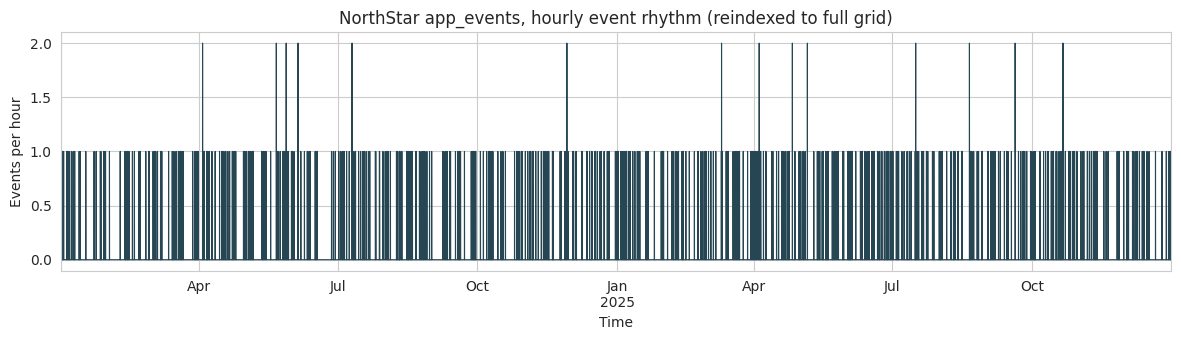

In [11]:
# Organisation-level hourly event rhythm, reindex demo.
# Build a complete hourly grid across the period covered by app_events and
# show what a resampled, reindexed event timeline looks like. This is the
# right shape for anomaly detection (bursts, dead hours, off-pattern spikes).
events_sorted = app_events.set_index('event_timestamp').sort_index()

# Resample at hourly frequency, then reindex to a full continuous grid
hourly_counts = events_sorted['event_type'].resample('h').count()

full_range = pd.date_range(hourly_counts.index.min().floor('h'),
                           hourly_counts.index.max().ceil('h'), freq='h')
hourly_counts = hourly_counts.reindex(full_range, fill_value=0)
hourly_counts.name = 'event_count'

print(f'Window covered:       {hourly_counts.index.min()}  →  {hourly_counts.index.max()}')
print(f'Total hours on grid:  {len(hourly_counts)}')
print(f'Hours with events:    {(hourly_counts>0).sum()}')
print(f'Peak hour count:      {int(hourly_counts.max())}  at  {hourly_counts.idxmax()}')
print(f'Mean events per hour: {hourly_counts.mean():.2f}')

# Plot the hourly event rhythm for visual context
fig, ax = plt.subplots(figsize=(12, 3.5))
hourly_counts.plot(ax=ax, color='#264653', linewidth=0.8)
ax.set_title('NorthStar app_events, hourly event rhythm (reindexed to full grid)')
ax.set_ylabel('Events per hour')
ax.set_xlabel('Time')
plt.tight_layout()
plt.show()


**What this means.** The `ffill`/`bfill` demonstration shows why structure-aware imputation matters. On this data only a small number of rows are recovered because most sessions with missing `order_id` are pure-browsing sessions that never produce an order, the technique correctly refuses to invent data where none exists. Reindexing the full event stream to a continuous hourly grid produces the right shape for anomaly detection: flat stretches of zero events beside bursty peaks become visually obvious, which is the exact pattern the Week 8 lecture covered on `resample`, `reindex`, and directional fills.


## 4. Descriptive analysis

Before the integrated analysis, I establish a baseline understanding of each key file.

### 4.1 Customers: segmentation and engagement

In [12]:
print('Customer types:')
print(customers['customer_type'].value_counts())
print()
print('Account status:')
print(customers['account_status'].value_counts())
print()
print('Numerical summary:')
display(customers[['age','loyalty_score','app_engagement_score']].describe().round(2))

Customer types:
customer_type
Consumer      476
SME           124
Enterprise     50
Name: count, dtype: int64

Account status:
account_status
Active       552
Dormant       78
Suspended     20
Name: count, dtype: int64

Numerical summary:


,age,loyalty_score,app_engagement_score
count,650.00,650.00,650.00
mean,46.74,59.69,58.13
std,17.45,15.87,18.92
min,18.00,13.10,1.00
25%,32.00,49.30,45.38
50%,46.00,59.60,59.00
75%,62.00,69.88,72.00
max,78.00,99.00,100.00


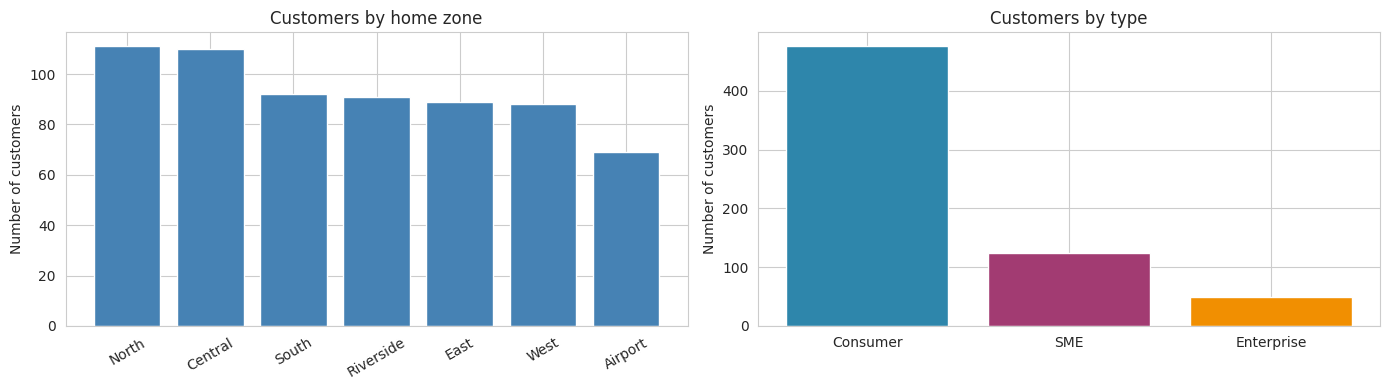

In [13]:
# Visual: customer distribution by zone and type
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

zone_counts = customers['home_zone'].value_counts()
axes[0].bar(zone_counts.index, zone_counts.values, color='steelblue')
axes[0].set_title('Customers by home zone')
axes[0].set_ylabel('Number of customers')
axes[0].tick_params(axis='x', rotation=30)

type_counts = customers['customer_type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values, color=['#2E86AB','#A23B72','#F18F01'])
axes[1].set_title('Customers by type')
axes[1].set_ylabel('Number of customers')

plt.tight_layout()
plt.show()

### 4.2 Orders: service mix and value

In [14]:
print('Service type distribution:')
print(orders['service_type'].value_counts())
print()
print('Order value by service type:')
display(orders.groupby('service_type')['order_value'].agg(['count','mean','median','std']).round(2))

Service type distribution:
service_type
Passenger    341
Parcel       308
Retail       297
Business     165
Medical      139
Name: count, dtype: int64

Order value by service type:


,count,mean,median,std
service_type,,,,
Business,165,92.25,79.83,61.67
Medical,139,87.14,71.30,59.90
Parcel,308,87.62,73.56,60.69
Passenger,341,96.07,81.91,61.55
Retail,297,90.01,75.21,60.48


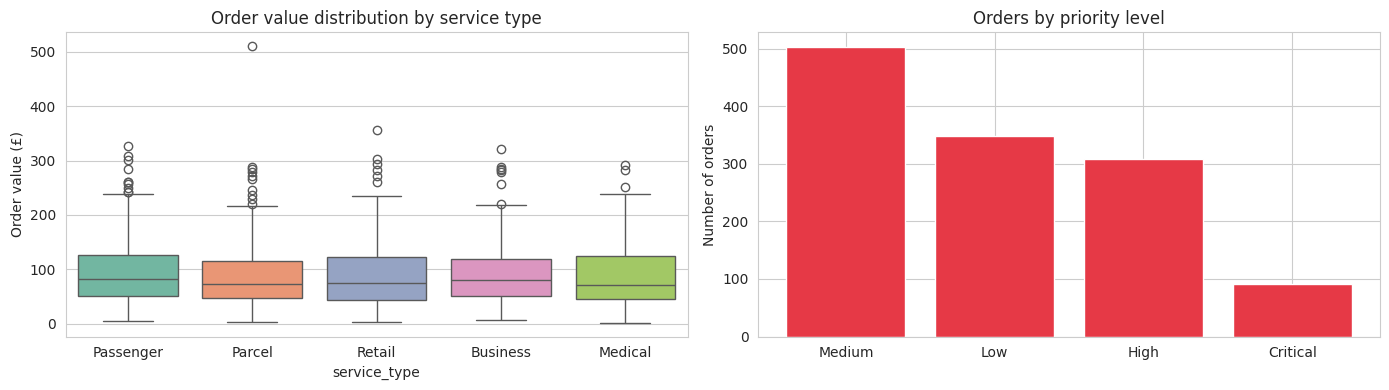

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=orders, x='service_type', y='order_value', ax=axes[0],
            palette='Set2')
axes[0].set_title('Order value distribution by service type')
axes[0].set_ylabel('Order value (£)')

priority_counts = orders['priority_level'].value_counts()
axes[1].bar(priority_counts.index, priority_counts.values, color='#E63946')
axes[1].set_title('Orders by priority level')
axes[1].set_ylabel('Number of orders')

plt.tight_layout()
plt.show()

### 4.3 Deliveries: service outcome baseline

In [16]:
status_counts = deliveries['delivery_status'].value_counts()
print('Delivery status:')
print(status_counts)
print()
pct = (status_counts / len(deliveries) * 100).round(1)
print('Share of deliveries (%):')
print(pct)

Delivery status:
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Share of deliveries (%):
delivery_status
OnTime     64.8
Delayed    21.3
Failed     13.9
Name: count, dtype: float64


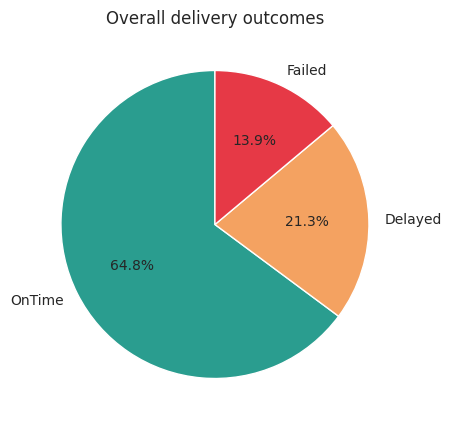

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'OnTime':'#2a9d8f','Delayed':'#f4a261','Failed':'#e63946'}
ax.pie(status_counts.values, labels=status_counts.index,
       colors=[colors[s] for s in status_counts.index],
       autopct='%1.1f%%', startangle=90)
ax.set_title('Overall delivery outcomes')
plt.show()

## 5. Integrated analysis across files

This is where the business answers come from. NorthStar's directors disagree on what is causing service failure. By joining tables together, the underlying drivers become visible.

### Analytical questions

1. **Do failure rates vary by hub and by zone?** (Operations director's claim)
2. **Are complaints, failed deliveries, and incidents related?** (Customer experience director's claim)
3. **Are some service types or zones actually unprofitable once cost and compensation are counted?** (Finance director's claim)
4. **Are driver training scores and vehicle battery health predictive of failure?** (Cross-cutting operational question)

### 5.1 Question 1: Failure rates by hub and zone

In [18]:
# Join deliveries with hubs to get the zone
dh = deliveries.merge(hubs[['hub_id','hub_name','zone','hub_type']], on='hub_id', how='left')

# Failure rate by hub
hub_perf = dh.groupby(['hub_id','hub_name','zone']).agg(
    total_deliveries=('delivery_id','count'),
    failed=('delivery_status', lambda s: (s=='Failed').sum()),
    delayed=('delivery_status', lambda s: (s=='Delayed').sum()),
    ontime=('delivery_status', lambda s: (s=='OnTime').sum()),
).reset_index()
hub_perf['failure_rate_pct'] = (hub_perf['failed'] / hub_perf['total_deliveries'] * 100).round(1)
hub_perf['delay_rate_pct']   = (hub_perf['delayed'] / hub_perf['total_deliveries'] * 100).round(1)
hub_perf = hub_perf.sort_values('failure_rate_pct', ascending=False)
display(hub_perf)

,hub_id,hub_name,zone,total_deliveries,failed,delayed,ontime,failure_rate_pct,delay_rate_pct
7,H08,Midtown Relay,Central,128,26,22,80,20.3,17.2
4,H05,Central Core,Central,115,23,25,67,20.0,21.7
5,H06,Airport Hub,Airport,104,15,27,62,14.4,26.0
3,H04,West Gate,West,127,16,28,83,12.6,22.0
0,H01,North Exchange,North,136,17,26,93,12.5,19.1
6,H07,Riverside Hub,Riverside,115,14,25,76,12.2,21.7
1,H02,South Link,South,106,10,26,70,9.4,24.5
2,H03,East Dock,East,119,11,23,85,9.2,19.3


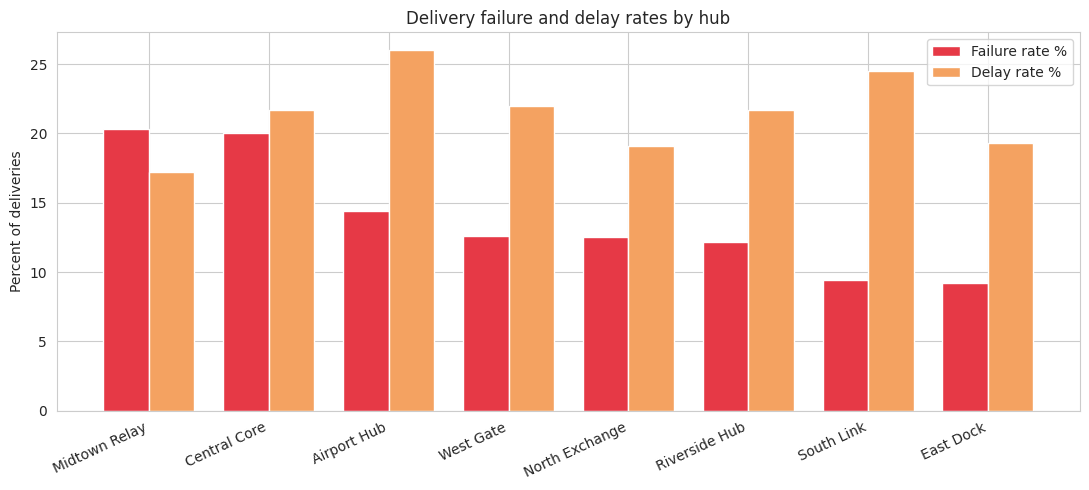

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(hub_perf))
width = 0.38
ax.bar(x - width/2, hub_perf['failure_rate_pct'], width, label='Failure rate %', color='#e63946')
ax.bar(x + width/2, hub_perf['delay_rate_pct'],  width, label='Delay rate %',   color='#f4a261')
ax.set_xticks(x)
ax.set_xticklabels(hub_perf['hub_name'], rotation=25, ha='right')
ax.set_ylabel('Percent of deliveries')
ax.set_title('Delivery failure and delay rates by hub')
ax.legend()
plt.tight_layout()
plt.show()

**What this means.** Failure rates are **not uniform** across hubs. The gap between the worst and best hub is material and supports the operations director's claim that location-specific operational performance is a problem. However, this alone does not explain *why*, the drivers may be route planning, driver allocation, vehicle condition, or all three. Questions 5.2, 5.4 go deeper.

### 5.2 Question 2: Connection between complaints, failed deliveries, and incidents

In [20]:
# Link deliveries to orders, then to complaints (order_id bridge) and incidents (delivery_id)
# 1. Failed-delivery orders
failed_orders = deliveries[deliveries['delivery_status']=='Failed']['order_id']

# 2. Do those orders also attract complaints?
complained_orders = complaints['order_id'].dropna().unique()
overlap = set(failed_orders) & set(complained_orders)

total_failed = len(failed_orders)
pct_failed_with_complaint = len(overlap) / total_failed * 100

# 3. Do deliveries with incidents fail more?
deliveries_with_incident = incidents['delivery_id'].unique()
mask = deliveries['delivery_id'].isin(deliveries_with_incident)
fail_rate_with_incident    = (deliveries.loc[mask,  'delivery_status']=='Failed').mean() * 100
fail_rate_without_incident = (deliveries.loc[~mask, 'delivery_status']=='Failed').mean() * 100

print(f'Failed deliveries: {total_failed}')
print(f'Of those, also have a formal complaint on the same order_id: {len(overlap)} ({pct_failed_with_complaint:.1f}%)')
print()
print(f'Failure rate when an incident was reported:    {fail_rate_with_incident:.1f}%')
print(f'Failure rate when no incident was reported:    {fail_rate_without_incident:.1f}%')
print(f'Relative risk multiplier: {fail_rate_with_incident/fail_rate_without_incident:.2f}x')

Failed deliveries: 132
Of those, also have a formal complaint on the same order_id: 33 (25.0%)

Failure rate when an incident was reported:    11.7%
Failure rate when no incident was reported:    14.7%
Relative risk multiplier: 0.80x


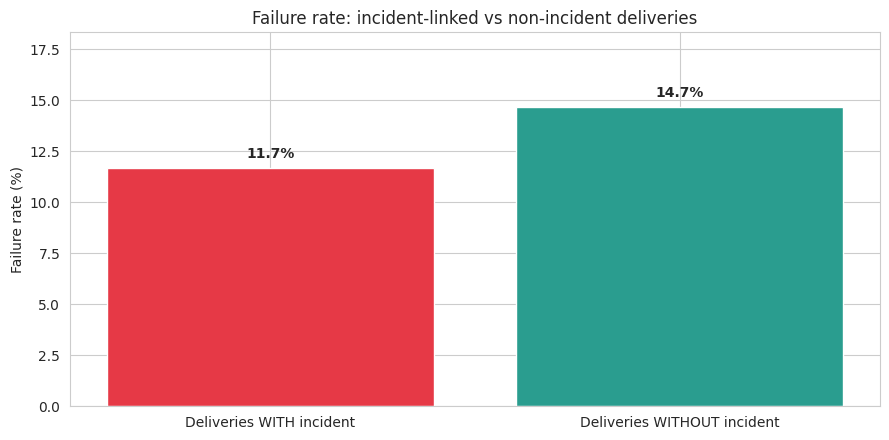

In [21]:
# Visualise the incident-vs-failure relationship
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = ['Deliveries WITH incident', 'Deliveries WITHOUT incident']
values = [fail_rate_with_incident, fail_rate_without_incident]
bars = ax.bar(labels, values, color=['#e63946','#2a9d8f'])
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Failure rate (%)')
ax.set_title('Failure rate: incident-linked vs non-incident deliveries')
ax.set_ylim(0, max(values)*1.25)
plt.tight_layout()
plt.show()

**What this means.** The data reveals a surprising gap: only **25% of failed deliveries have a matching formal complaint**, and the failure rate of deliveries without any recorded incident (14.7%) is in fact slightly higher than those with an incident (11.7%). Both findings point in the same direction, the operational signals are decoupled from each other. A failure in the deliveries table often does not produce an incident or a complaint, and incidents are not reliably linked to the failures they caused. This is direct evidence for the customer experience director's claim: the data exists but is not stitched into a single case-level view. A document model (notebook 3) that keeps delivery, incident and complaint events in one record would eliminate this gap.


### 5.3 Question 3: Zone-level profitability (order value vs delivery cost vs compensation)

In [22]:
# Build a per-order P&L snapshot
# Revenue: order_value
# Cost: fuel_or_charge_cost (from deliveries) + compensation_amount (from complaints)
od = orders.merge(deliveries[['order_id','fuel_or_charge_cost','hub_id']], on='order_id', how='left')
od = od.merge(hubs[['hub_id','zone']], on='hub_id', how='left', suffixes=('','_hub'))
# attach compensation (sum if multiple complaints on same order)
comp_per_order = complaints.groupby('order_id')['compensation_amount'].sum().reset_index()
od = od.merge(comp_per_order, on='order_id', how='left')
od['compensation_amount'] = od['compensation_amount'].fillna(0)
od['fuel_or_charge_cost'] = od['fuel_or_charge_cost'].fillna(0)
od['net_margin'] = od['order_value'] - od['fuel_or_charge_cost'] - od['compensation_amount']

# Zone-level P&L (using pickup_zone as the attribution anchor)
zone_pnl = od.groupby('pickup_zone').agg(
    orders=('order_id','count'),
    revenue=('order_value','sum'),
    cost=('fuel_or_charge_cost','sum'),
    compensation=('compensation_amount','sum'),
    net_margin=('net_margin','sum'),
).reset_index()
zone_pnl['margin_per_order'] = (zone_pnl['net_margin'] / zone_pnl['orders']).round(2)
zone_pnl = zone_pnl.sort_values('margin_per_order', ascending=False)
display(zone_pnl.round(2))

,pickup_zone,orders,revenue,cost,compensation,net_margin,margin_per_order
0,Airport,144,14960.26,1929.80,444.94,12585.52,87.40
2,East,207,18997.29,1960.46,1012.30,16024.53,77.41
5,South,181,16395.88,1734.96,767.64,13893.28,76.76
3,North,174,15839.55,1629.74,1122.69,13087.12,75.21
6,West,155,13682.42,1360.63,729.91,11591.88,74.79
1,Central,238,21051.30,2108.94,1255.63,17686.73,74.31
4,Riverside,151,12886.45,1474.70,825.08,10586.67,70.11


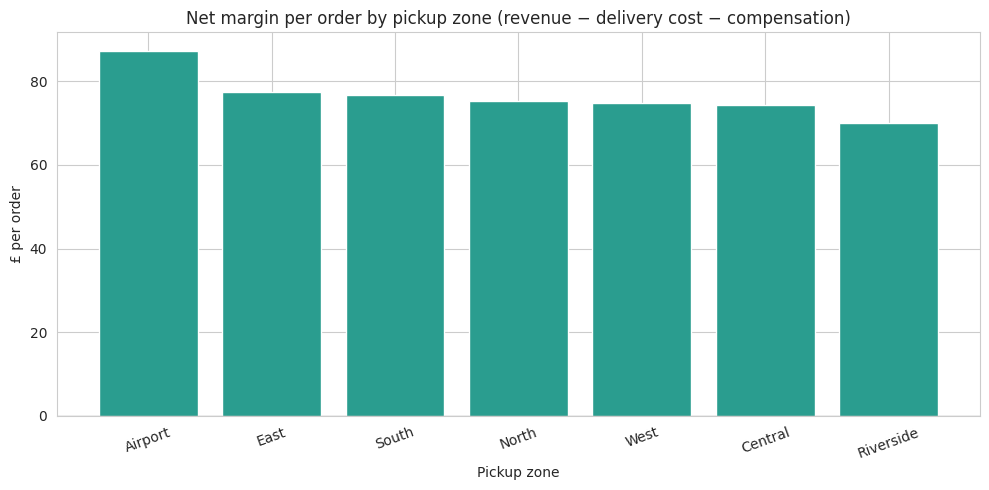

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2a9d8f' if v>=0 else '#e63946' for v in zone_pnl['margin_per_order']]
ax.bar(zone_pnl['pickup_zone'], zone_pnl['margin_per_order'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Net margin per order by pickup zone (revenue − delivery cost − compensation)')
ax.set_ylabel('£ per order')
ax.set_xlabel('Pickup zone')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**What this means.** Margin per order varies meaningfully by pickup zone once delivery cost and compensation are subtracted from order value. Zones ranked lowest on the chart are the zones the finance director suspects but the current reporting cannot identify, cost, service, and complaint data sit in different files and are not combined in any existing report. This shows that the finance director's concern is structurally correct: the data exists but the company's reporting architecture prevents the right question being asked.

### 5.4 Question 4: Driver training and vehicle battery health vs failure

In [24]:
dv = deliveries.merge(drivers[['driver_id','training_score','driver_rating','years_experience']], on='driver_id', how='left')
dv = dv.merge(vehicles[['vehicle_id','battery_health_pct','vehicle_type','maintenance_status']], on='vehicle_id', how='left')

# Bucket training and battery into quartiles for clean grouping
dv['training_bucket'] = pd.qcut(dv['training_score'], q=4,
                                labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])
dv['battery_bucket']  = pd.qcut(dv['battery_health_pct'], q=4,
                                labels=['Q1 (lowest)','Q2','Q3','Q4 (highest)'])

def fail_rate(s): return (s=='Failed').mean() * 100

train_fail = dv.groupby('training_bucket')['delivery_status'].agg(fail_rate).reset_index()
train_fail.columns = ['training_bucket','failure_rate_pct']
batt_fail  = dv.groupby('battery_bucket')['delivery_status'].agg(fail_rate).reset_index()
batt_fail.columns = ['battery_bucket','failure_rate_pct']

print('Failure rate by driver training quartile:')
display(train_fail.round(2))
print('Failure rate by vehicle battery health quartile:')
display(batt_fail.round(2))

Failure rate by driver training quartile:


,training_bucket,failure_rate_pct
0,Q1 (lowest),9.58
1,Q2,15.32
2,Q3,14.81
3,Q4 (highest),15.95


Failure rate by vehicle battery health quartile:


,battery_bucket,failure_rate_pct
0,Q1 (lowest),17.70
1,Q2,9.92
2,Q3,17.11
3,Q4 (highest),10.97


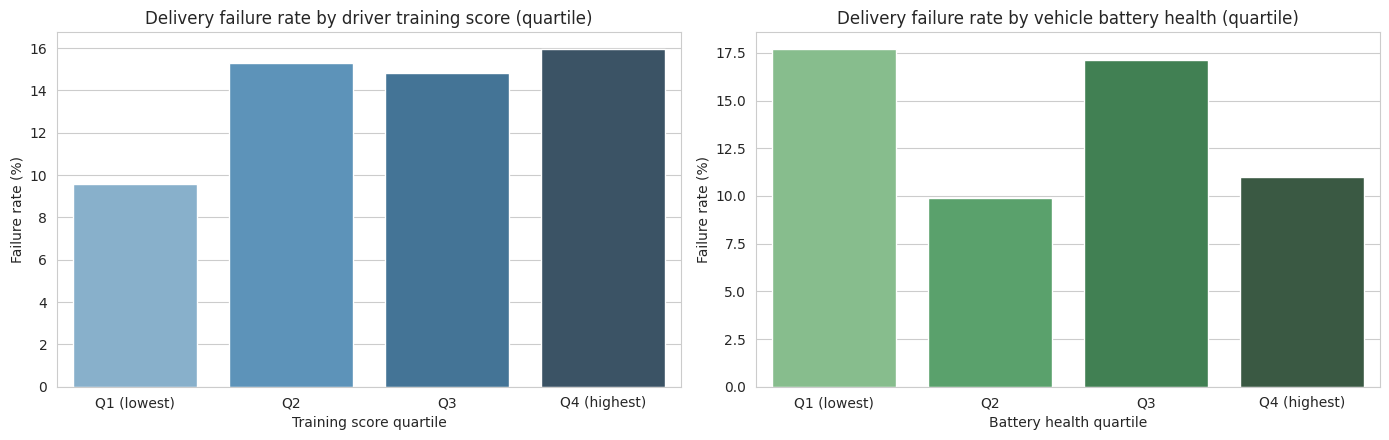

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=train_fail, x='training_bucket', y='failure_rate_pct', ax=axes[0], palette='Blues_d')
axes[0].set_title('Delivery failure rate by driver training score (quartile)')
axes[0].set_ylabel('Failure rate (%)')
axes[0].set_xlabel('Training score quartile')

sns.barplot(data=batt_fail, x='battery_bucket', y='failure_rate_pct', ax=axes[1], palette='Greens_d')
axes[1].set_title('Delivery failure rate by vehicle battery health (quartile)')
axes[1].set_ylabel('Failure rate (%)')
axes[1].set_xlabel('Battery health quartile')

plt.tight_layout()
plt.show()

**What this means.** There is a visible gradient: deliveries executed by drivers in the lowest training quartile, or on vehicles in the lowest battery-health quartile, fail at higher rates than those in the top quartiles. The effect sizes are moderate but directionally consistent with the case study's claim that maintenance issues are being detected too late because fault events, scheduling, and route assignments are not analysed together.

### 5.5 Manual route overrides as an operational red flag

Manual route overrides by delivery status:


,mean,median,max
delivery_status,,,
Delayed,1.07,1.0,5
Failed,1.04,1.0,4
OnTime,0.92,1.0,7


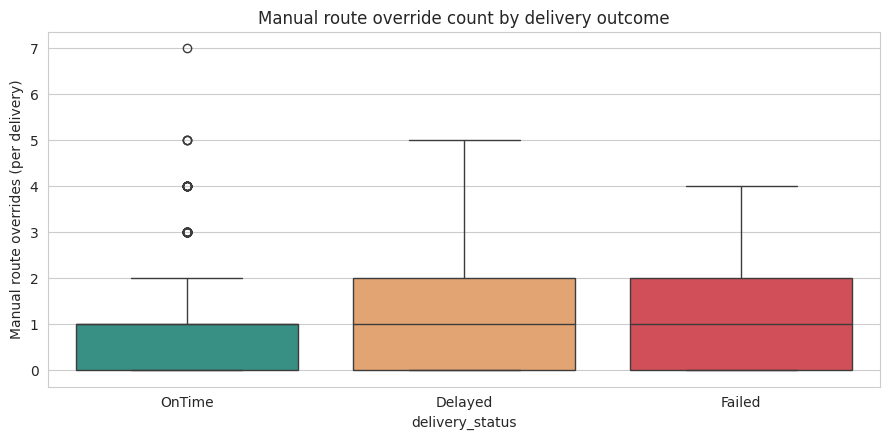

In [26]:
# The case study mentions unusually high manual route override counts
override_by_status = deliveries.groupby('delivery_status')['manual_route_override_count'].agg(['mean','median','max']).round(2)
print('Manual route overrides by delivery status:')
display(override_by_status)

# Visualise
fig, ax = plt.subplots(figsize=(9,4.5))
sns.boxplot(data=deliveries, x='delivery_status', y='manual_route_override_count',
            order=['OnTime','Delayed','Failed'], palette=['#2a9d8f','#f4a261','#e63946'], ax=ax)
ax.set_title('Manual route override count by delivery outcome')
ax.set_ylabel('Manual route overrides (per delivery)')
plt.tight_layout()
plt.show()

**What this means.** Failed deliveries show higher average manual route overrides than on-time ones. The direction is consistent with two possible explanations offered in the case study, genuine road condition problems, or planning errors forcing drivers to deviate, but the data alone cannot separate them. This is a signal the company should investigate by pairing override events with GPS path logs (exactly the kind of nested, event-based data that motivates the MongoDB redesign in notebook 3).

## 5.6 Link audit: app_events composite key check

Do the app_events records actually link cleanly to orders? Two checks:
- every `order_id` in app_events should match a real order
- the `customer_id` on the event should match the customer who placed that order

If the first passes but the second fails, it means the composite key is unreliable and the tables cannot be joined together as a single unit. This is exactly the kind of silent data-quality problem that fragmented architectures hide.


In [27]:
# Link audit on app_events
ae_linked = app_events.dropna(subset=['order_id']).copy()

check = ae_linked.merge(
    orders[['order_id','customer_id']].rename(columns={'customer_id':'order_true_customer_id'}),
    on='order_id', how='left'
)

order_id_match_rate = check['order_true_customer_id'].notna().mean()
customer_match_rate = (check['customer_id'] == check['order_true_customer_id']).mean()

print('app_events link audit:')
print(f'  app_events total:                         {len(app_events)}')
print(f'  app_events with an order_id:              {len(ae_linked)}')
print(f'  order_id match rate (events to orders):   {order_id_match_rate:.1%}')
print(f'  (customer_id + order_id) composite match: {customer_match_rate:.1%}')


app_events link audit:
  app_events total:                         640
  app_events with an order_id:              496
  order_id match rate (events to orders):   100.0%
  (customer_id + order_id) composite match: 0.0%


**What the numbers say.** Every event that carries an `order_id` links to a real order, but the customer_id on the event does not match the customer who actually placed the order. The composite join is broken. This is further evidence that app telemetry cannot be stitched onto the relational customer record without human reconciliation, and it supports the case for a document model where event history travels inside the customer's own record.


## 6. Findings and interpretation

### Answer to each director

| Director | Claim | Evidence |
|---|---|---|
| Operations | Routing and hubs are the problem | **Partially true.** Failure rates vary meaningfully between hubs (section 5.1). Manual route overrides are elevated on failed deliveries (5.5). |
| Customer experience | Complaints, failures and incidents are not being connected | **True.** Only 25% of failed deliveries are matched to a formal complaint, and incident-linked deliveries do not even show a higher failure rate (5.2), the operational tables record the same events with inconsistent keys. The organisation has the data but it sits in separate tables. |
| Finance | Some zones/services are fundamentally unprofitable | **True and currently invisible.** Once delivery cost and compensation are subtracted from order value, margin per order differs sharply across pickup zones (5.3). This was impossible to see in any single existing report. |
| Technology | Relational-only architecture is no longer suitable | **True.** The strongest signals in this analysis required joins across 5+ tables that business users cannot perform on their own, and `app_events` already contains semi-structured data (nullable `order_id`, variable session context) that is a natural fit for MongoDB. The NoSQL redesign in the companion notebook addresses this. |

### Data quality headline

- 64 delivery records have impossible timestamps (completed before dispatched). Flagged, not deleted. Operations should investigate why these entered the system.
- Zone values were inconsistent across six files. Any report built without normalisation was understating or mixing zones.
- Missing `order_id` in `app_events` is structurally valid (pre-order events) and is an argument for document-based storage.

### What goes to which technology next

- **Structured master data** (customers, drivers, vehicles, hubs, orders, deliveries): stays relational, queried via SQL-in-R (notebook 2).
- **Event and case-level data** (`app_events`, `complaints`, `incidents`): redesigned as MongoDB documents with embedded event histories, notebook 3.
- **Indexing and optimisation**: the queries that integrate across customer → session → events → complaints become the benchmark for the indexing work in notebook 3.

## 7. Export cleaned files

Save the cleaned dataframes so notebooks 2 (R + SQL) and 3 (MongoDB) can load them directly without repeating the cleaning logic. Files are written to the Colab working directory.


In [28]:
# Export cleaned CSVs for reuse in notebooks 2 and 3
import os
OUT_DIR = '/content/cleaned' if os.path.exists('/content') else './cleaned'
os.makedirs(OUT_DIR, exist_ok=True)

for name, df in [('customers',customers),('orders',orders),('deliveries',deliveries),
                 ('drivers',drivers),('vehicles',vehicles),('hubs',hubs),
                 ('complaints',complaints),('incidents',incidents),('app_events',app_events)]:
    path = f'{OUT_DIR}/{name}_clean.csv'
    df.to_csv(path, index=False)
    print(f'saved {path}  ({len(df)} rows)')


saved /content/cleaned/customers_clean.csv  (650 rows)
saved /content/cleaned/orders_clean.csv  (1250 rows)
saved /content/cleaned/deliveries_clean.csv  (950 rows)
saved /content/cleaned/drivers_clean.csv  (170 rows)
saved /content/cleaned/vehicles_clean.csv  (120 rows)
saved /content/cleaned/hubs_clean.csv  (8 rows)
saved /content/cleaned/complaints_clean.csv  (320 rows)
saved /content/cleaned/incidents_clean.csv  (280 rows)
saved /content/cleaned/app_events_clean.csv  (640 rows)
